# Algorytmika i matematyka uczenia maszynowego 
## Laboratorium 12 - przekształcenia geometryczne






### Zadanie 1

1) Utwórz macierz współrzędnych punktów reprezentującą figurę geometryczną, składającą się z co najmniej 4 punktów. Figura powinna mieć "punkt centralny" znajdujący się (w przybliżeniu, nie musi być dokładnie) w punkcie `(0, 0)`.

2) Wyświetl utworzoną figurę na wykresie za pomocą biblioteki `matplotlib`. Upewnij się, że wykres jest czytelny (np. dodaj kolor wypełnienia figury i oznaczenia osi).

> Podpowiedź: możesz użyć funkcji [`plt.fill`](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.pyplot.fill.html)

Kolejne zadania wykonuj, używając macierzy utworzonej w tym zadaniu, chyba że w treści zadania wskazano inaczej.


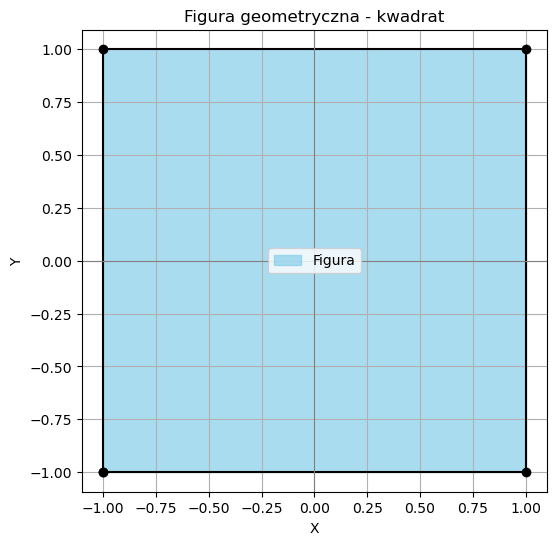

In [17]:
import numpy as np
import matplotlib.pyplot as plt

points = np.array([
    [-1, -1],
    [1, -1],
    [1, 1],
    [-1, 1],
    [-1, -1] 
])

x = points[:, 0]
y = points[:, 1]

plt.figure(figsize=(6,6))
plt.fill(x, y, color='skyblue', alpha=0.7, label='Figura')
plt.plot(x, y, 'ko-') 
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Figura geometryczna - kwadrat')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


### Zadanie 2

Aby wykonać przekształcenie należy pomnożyć _macierz przekształcaną_ przez _macierz przekształcenia_. Poniżej wymienione są przykładowe macierze przekształceń pozwalające wykonać tranformacje:


Obrót o kąt $\theta$:

$$
A_\theta = \begin{pmatrix}
\text{cos}\theta & -\text{sin}\theta\\
\text{sin}\theta & \text{cos}\theta
\end{pmatrix}
$$

Rozciągnięcie wzdłuż osi $0x$:

$$
A_k = \begin{pmatrix}
k & 0\\
0 & 1
\end{pmatrix}
$$

Rozciągnięcie wzdłuż osi $0y$:

$$
A_k = \begin{pmatrix}
1 & 0\\
0 & k
\end{pmatrix}
$$

Rozciągnięcie w proporcji $k_x$ wzdłuż osi $0x$ i w proporcji $k_y$ wzdłuż osi $0y$:

$$
A_k = \begin{pmatrix}
k_x & 0\\
0 & k_y
\end{pmatrix}
$$

Pochylenie względem osi $0y$:

$$
A_k = \begin{pmatrix}
1 & k\\
0 & 1
\end{pmatrix}
$$

Pochylenie względem osi $0x$:

$$
A_k = \begin{pmatrix}
1 & 0\\
k & 1
\end{pmatrix}
$$



**Polecenie**

Utwórz trzy animacje dla obrotu, rozciągnięcia i pochylenia (odpowiednio).


Przykład:

<div style="display: flex; flex-direction: row; flex-wrap: wrap; justify-content: center; width:100%;">
<img src="./Figure_2_rot.gif" height="300" width="300" />
<img src="./Figure_2_strech.gif" height="300" width="300" />
<img src="./Figure_2_shear.gif" height="300" width="300" />
</div>


Przykład tworzenia animacji:

```python
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation
import numpy as np

fig, ax = plt.subplots(figsize=(8,8))

X = [1, 2, 3, 4]

def animate(i):
    ax.clear()
    ax.set_title(f'{i=}')
    ax.set_xlim(0,5)
    ax.set_ylim(1,10**16)
    ax.set_yscale('log')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.bar(X, [X[0]+i, X[1]*i, X[2]**i, i**X[3]] )

ani = matplotlib.animation.FuncAnimation(fig, animate, frames=36, interval=100, repeat=True) 
ani.save('tmp.gif', writer='imagemagick', fps=100)
```

In [18]:
import matplotlib.animation as animation

fig1, ax1 = plt.subplots(figsize=(6,6))

def animate_rotation(i):
    ax1.clear()
    theta = np.deg2rad(i)
    rot_matrix = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    rotated = points @ rot_matrix.T
    ax1.fill(rotated[:,0], rotated[:,1], color='skyblue', alpha=0.7)
    ax1.plot(rotated[:,0], rotated[:,1], 'ko-')
    ax1.axhline(0, color='gray', linewidth=0.8)
    ax1.axvline(0, color='gray', linewidth=0.8)
    ax1.set_xlim(-2, 2)
    ax1.set_ylim(-2, 2)
    ax1.set_title('Obrót')
    ax1.set_aspect('equal')
    ax1.grid(True)

ani_rot = animation.FuncAnimation(fig1, animate_rotation, frames=np.arange(0, 361, 5), interval=50)
plt.close(fig1)
ani_rot.save('exercise_2_rotation.gif', writer='pillow', fps=20)

fig2, ax2 = plt.subplots(figsize=(6,6))

def animate_stretch(i):
    ax2.clear()
    k = 1 + 0.01 * i 
    stretch_matrix = np.array([
        [k, 0],
        [0, 1]
    ])
    stretched = points @ stretch_matrix.T
    ax2.fill(stretched[:,0], stretched[:,1], color='lightgreen', alpha=0.7)
    ax2.plot(stretched[:,0], stretched[:,1], 'ko-')
    ax2.axhline(0, color='gray', linewidth=0.8)
    ax2.axvline(0, color='gray', linewidth=0.8)
    ax2.set_xlim(-3, 3)
    ax2.set_ylim(-2, 2)
    ax2.set_title('Rozciągnięcie wzdłuż osi X')
    ax2.set_aspect('equal')
    ax2.grid(True)

ani_stretch = animation.FuncAnimation(fig2, animate_stretch, frames=np.arange(0, 150, 3), interval=50)
plt.close(fig2)
ani_stretch.save('exercise_2_stretch.gif', writer='pillow', fps=20)

fig3, ax3 = plt.subplots(figsize=(6,6))

def animate_shear(i):
    ax3.clear()
    k = 0.01 * i 
    shear_matrix = np.array([
        [1, k],
        [0, 1]
    ])
    sheared = points @ shear_matrix.T
    ax3.fill(sheared[:,0], sheared[:,1], color='salmon', alpha=0.7)
    ax3.plot(sheared[:,0], sheared[:,1], 'ko-')
    ax3.axhline(0, color='gray', linewidth=0.8)
    ax3.axvline(0, color='gray', linewidth=0.8)
    ax3.set_xlim(-2, 4)
    ax3.set_ylim(-2, 2)
    ax3.set_title('Pochylenie względem osi X')
    ax3.set_aspect('equal')
    ax3.grid(True)

ani_shear = animation.FuncAnimation(fig3, animate_shear, frames=np.arange(0, 150, 3), interval=50)
plt.close(fig3)
ani_shear.save('exercise_2_shear.gif', writer='pillow', fps=20)

### Zadanie 3 (przekształcenia afiniczne)

Przekształcenia afiniczne pozwalają na wykonywanie operacji _translacji_ i łączenia jej z innymi operacjami przekształcenia. 
Aby wykonać przekształcenie afiniczne należy zmienić reprezentację punktu $(x, y) \in R^2$ na $(x, y, 1) \in R^3$. W ten sposób macierz przekształceń osiąga wymiar 3x3. Macierz pozwalająca wykonanie operacji translacji (przesunięcie o wektor $[k_x, k_y]$) wygląda wtedy następująco:



$$
A_k = \begin{pmatrix}
1 & 0 & k_x \\
0 & 1 & k_y \\
0 & 0 & 1
\end{pmatrix}
$$


Pozostałe operacje analogicznie jak wcześniej, np. operacja obrotu:

$$
A_\theta = \begin{pmatrix}
\text{cos}\theta & -\text{sin}\theta & 0\\
\text{sin}\theta & \text{cos}\theta & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

**Polecenie**

Wykonaj animację, gdzie operacja translacji oraz obrotu są wykonywane za pomocą jednej operacji macierzowej.

> Podpowiedź: należy "połączyć" macierze przekształceń w jedną.


Przykład:

<img src="./Figure_3.gif" height="300" width="300" />

In [24]:
fig4, ax4 = plt.subplots(figsize=(6,6))

def animate_affine(i):
    ax4.clear()
    
    theta = np.deg2rad(i)
    tx = 2 * np.cos(theta)
    ty = 2 * np.sin(theta)
    
    rot = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    
    trans = np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ])
    
    affine = trans @ rot

    points_aug = np.vstack([points.T, np.ones(points.shape[0])])
    transformed = (affine @ points_aug).T 

    ax4.fill(transformed[:, 0], transformed[:, 1], color='violet', alpha=0.7)
    ax4.plot(transformed[:, 0], transformed[:, 1], 'ko-')
    ax4.axhline(0, color='gray', linewidth=0.8)
    ax4.axvline(0, color='gray', linewidth=0.8)
    ax4.set_xlim(-4, 4)
    ax4.set_ylim(-4, 4)
    ax4.set_title('Obrót + translacja (afiniczne)')
    ax4.set_aspect('equal')
    ax4.grid(True)


ani_affine = animation.FuncAnimation(fig4, animate_affine, frames=np.arange(0, 361, 5), interval=50)
plt.close(fig4)
ani_affine.save('exercise_3_affine.gif', writer='pillow', fps=20)


### Zadanie 4 (przekształcenia macierzowe w 3D)

1) Utwórz prostą figurę geometryczną złożoną z 8 punktów w przestrzeni 3D (podobnie jak w pierwszym zadaniu).

Przykład:

```python
fig = plt.figure()
ax = Axes3D(fig)

m = np.array([
    [-1, -1, -1],
    [-1, 2, -1],
    [2, -1, -1],
    [2, 2, -1],
    [-1, -1, 2],
    [-1, 2, 2],
    [2, -1, 2],
    [2, 2, 2]
])

ax.scatter(m[:, 0], m[:, 1], m[:, 2])
```

2) Utwórz animację obrotu figury względem osi $0z$.

> Aby wykonać taki obrót należy użyć poniższej macierzy przekształceń:
$$
A_\theta = \begin{pmatrix}
\text{cos}\theta & -\text{sin}\theta & 0\\
\text{sin}\theta & \text{cos}\theta & 0 \\
0 & 0 & 1
\end{pmatrix}
$$

**Przykład**


<img src="./Figure_4.gif" height="300" width="300" />

In [20]:
from mpl_toolkits.mplot3d import Axes3D

cube_points = np.array([
    [-1, -1, -1],
    [-1,  1, -1],
    [ 1,  1, -1],
    [ 1, -1, -1],
    [-1, -1,  1],
    [-1,  1,  1],
    [ 1,  1,  1],
    [ 1, -1,  1]
])

fig5 = plt.figure(figsize=(7,7))
ax5 = fig5.add_subplot(111, projection='3d')

def animate_cube_rotation(i):
    ax5.clear()
    theta = np.deg2rad(i)
    rot_z = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    rotated = cube_points @ rot_z.T
    ax5.scatter(rotated[:,0], rotated[:,1], rotated[:,2], color='royalblue', s=60)
    ax5.set_xlim(-2, 2)
    ax5.set_ylim(-2, 2)
    ax5.set_zlim(-2, 2)
    ax5.set_xlabel('X')
    ax5.set_ylabel('Y')
    ax5.set_zlabel('Z')
    ax5.set_title('Obrót sześcianu wokół osi Z')
    ax5.view_init(elev=20, azim=30)
    ax5.grid(True)

ani_cube = animation.FuncAnimation(fig5, animate_cube_rotation, frames=np.arange(0, 361, 5), interval=50)
plt.close(fig5)
ani_cube.save('exercise_4_cube_rotation.gif', writer='pillow', fps=20)

### Zadanie 5

Połącz punkty (jeżeli nie zrobiłeś tego wcześniej) figury z poprzedniego zadania.

<img src="./Figure_5.gif" height="300" width="300" />

In [21]:
cube_edges = [
    (0, 1), (1, 2), (2, 3), (3, 0),
    (4, 5), (5, 6), (6, 7), (7, 4),
    (0, 4), (1, 5), (2, 6), (3, 7)
]

fig6 = plt.figure(figsize=(7,7))
ax6 = fig6.add_subplot(111, projection='3d')

def animate_cube_edges(i):
    ax6.clear()
    theta = np.deg2rad(i)
    rot_z = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta),  np.cos(theta), 0],
        [0, 0, 1]
    ])
    rotated = cube_points @ rot_z.T
    ax6.scatter(rotated[:,0], rotated[:,1], rotated[:,2], color='royalblue', s=60)
    for start, end in cube_edges:
        xs = [rotated[start,0], rotated[end,0]]
        ys = [rotated[start,1], rotated[end,1]]
        zs = [rotated[start,2], rotated[end,2]]
        ax6.plot(xs, ys, zs, color='black')
    ax6.set_xlim(-2, 2)
    ax6.set_ylim(-2, 2)
    ax6.set_zlim(-2, 2)
    ax6.set_xlabel('X')
    ax6.set_ylabel('Y')
    ax6.set_zlabel('Z')
    ax6.set_title('Obrót sześcianu z krawędziami')
    ax6.view_init(elev=20, azim=30)
    ax6.grid(True)

ani_cube_edges = animation.FuncAnimation(fig6, animate_cube_edges, frames=np.arange(0, 361, 5), interval=50)
plt.close(fig6)
ani_cube_edges.save('exercise_5_cube_edges.gif', writer='pillow', fps=20)
